# 📉 VARMA: Vector AutoRegressive Moving Average

## 1. What is VARMA?
**VARMA($p, q$)** is the multivariate generalization of the ARIMA model (specifically the AR and MA parts). It combines two powerful forces to model a system of related time series:

1.  **VAR ($p$): Vector AutoRegression**
    * Models the relationship between the *current value* of a variable and the *past values* of **all** variables in the system.
    * *Concept:* "Past Trends predict Future."
2.  **VMA ($q$): Vector Moving Average**
    * Models the relationship between the *current value* and the *past forecast errors (residuals)* of **all** variables in the system.
    * *Concept:* "Past Shocks/Surprises predict Future correction."

## 2. Why do we need it? (The "Parsimony" Principle)
If **VAR** is so powerful, why add the complexity of **MA**?
* **The Problem:** To capture long-term dependencies with a simple VAR model, you often need a very high lag order (e.g., VAR(12)). This requires estimating hundreds of coefficients ("Parameter Explosion"), leading to overfitting.
* **The Solution:** Adding a Moving Average ($q$) term can often capture the same complex structure with very few parameters. A **VARMA(1,1)** can sometimes replace a **VAR(12)**. This efficiency is called **Parsimony**.

---

## 3. The Mathematical Derivation

Let $Y_t$ be a vector of $k$ endogenous variables (e.g., $GDP$ and $Inflation$) at time $t$.

### Step A: The VAR Part (Autoregression)
This looks at past values ($Y_{t-1}$).
$$Y_{VAR} = C + A_1 Y_{t-1} + A_2 Y_{t-2} + \dots + A_p Y_{t-p}$$
* $A_i$: Matrices of coefficients for the variables.

### Step B: The VMA Part (Moving Average)
This looks at past errors ($\epsilon_{t-1}$).
$$Y_{VMA} = \epsilon_t + M_1 \epsilon_{t-1} + M_2 \epsilon_{t-2} + \dots + M_q \epsilon_{t-q}$$
* $\epsilon_t$: The "White Noise" error vector (current shock).
* $M_j$: Matrices of coefficients for the errors.

### Step C: The Combined VARMA Equation
We sum them up to get the full model:

$$Y_t = C + \underbrace{\sum_{i=1}^{p} A_i Y_{t-i}}_{\text{Past Values}} + \epsilon_t + \underbrace{\sum_{j=1}^{q} M_j \epsilon_{t-j}}_{\text{Past Shocks}}$$

---

## 4. The Modeling Workflow
Building a VARMA model is stricter than standard ARIMA.

1.  **Stationarity:** All variables **must** be stationary. (Use ADF Test). If not, apply Differencing.
2.  **Model Selection:** We rarely use `auto_arima` here. We typically rely on **AIC/BIC** scores to choose $p$ and $q$.
    * *Note:* VARMA is computationally heavy. We usually keep $p$ and $q$ small (e.g., 1 or 2).
3.  **Inversion:** If we differenced the data in Step 1, the model will forecast "Changes". We must mathematicaly "undifference" (Integrate) the forecast to get real values.

#### 1) Importing Necessary Libraries:

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

#### 2) Creating Data:

In [2]:
np.random.seed(42)
n_obs= 200

# Generating 2 Correlated Random Walks:
mean = [0, 0]
cov = [[1, 0.6], [0.6, 1]] # 0.6 correlation between shocks
errors = np.random.multivariate_normal(mean= mean,
                                      cov= cov,
                                      size= n_obs)

# Integrating to make them Non-Stationary:
d1 = np.cumsum(errors[:, 0]) + 100
d2 = np.cumsum(errors[:, 1]) + 100

# Creating Dataframe:
df = pd.DataFrame({'Econ_A': d1,
                  'Econ_B': d2})

In [11]:
df.shape

(200, 2)

##### Visualizing Data:

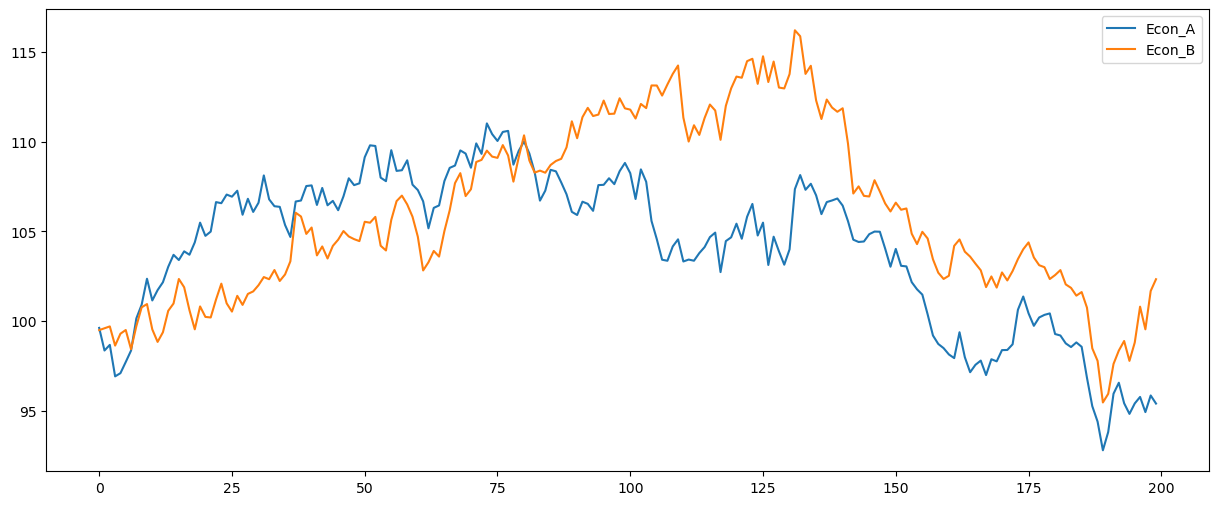

In [3]:
df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) Checking for Stationarity:

In [4]:
from statsmodels.tsa.stattools import adfuller

def dickey_fuller_result(series):
    """
    Function To Perform Augmenter Dickey-Fuller Test and Display Results.
    """
    
    result= adfuller(series.dropna())
    
    labels = ["Test Statistics", "p-Value", "No. of Lags", "No. of Observations"]
    
    output = pd.Series(result[0:4], index= labels)
    
    for key,value in result[4].items():
        output[f"Critical Value {key}"] = value
        
    print(output)
    
    print("\n")
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis.")
        print("Reject the null hypothesis.")
        print("Data has no unit root and is stationary.")
    else:
        print("Weak evidence against the null hypothesis.")
        print("Fail to reject the null hypothesis.")
        print("Data has a unit root and is non-stationary.")

In [5]:
dickey_fuller_result(df['Econ_A'])

Test Statistics         -1.085697
p-Value                  0.720742
No. of Lags              0.000000
No. of Observations    199.000000
Critical Value 1%       -3.463645
Critical Value 5%       -2.876176
Critical Value 10%      -2.574572
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


In [7]:
dickey_fuller_result(df['Econ_B'])

Test Statistics         -1.624792
p-Value                  0.470218
No. of Lags              0.000000
No. of Observations    199.000000
Critical Value 1%       -3.463645
Critical Value 5%       -2.876176
Critical Value 10%      -2.574572
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


`Both Series are Non-Stationary.`

##### Applying First Order Differencing:

In [8]:
df_diff = df.diff(periods= 1).dropna()

In [10]:
df_diff.head()

,Econ_A,Econ_B
1,-1.260430,0.101809
2,0.314142,0.104724
3,-1.755698,-1.069284
4,0.177270,0.662551
5,0.622774,0.206213


In [13]:
df_diff.shape

(199, 2)

In [14]:
dickey_fuller_result(df_diff['Econ_A'])

Test Statistics       -1.459956e+01
p-Value                4.187112e-27
No. of Lags            0.000000e+00
No. of Observations    1.980000e+02
Critical Value 1%     -3.463815e+00
Critical Value 5%     -2.876251e+00
Critical Value 10%    -2.574611e+00
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


In [15]:
dickey_fuller_result(df_diff['Econ_B'])

Test Statistics       -1.367445e+01
p-Value                1.439089e-25
No. of Lags            0.000000e+00
No. of Observations    1.980000e+02
Critical Value 1%     -3.463815e+00
Critical Value 5%     -2.876251e+00
Critical Value 10%    -2.574611e+00
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


`Both Series are Stationary after First Order Differencing.`

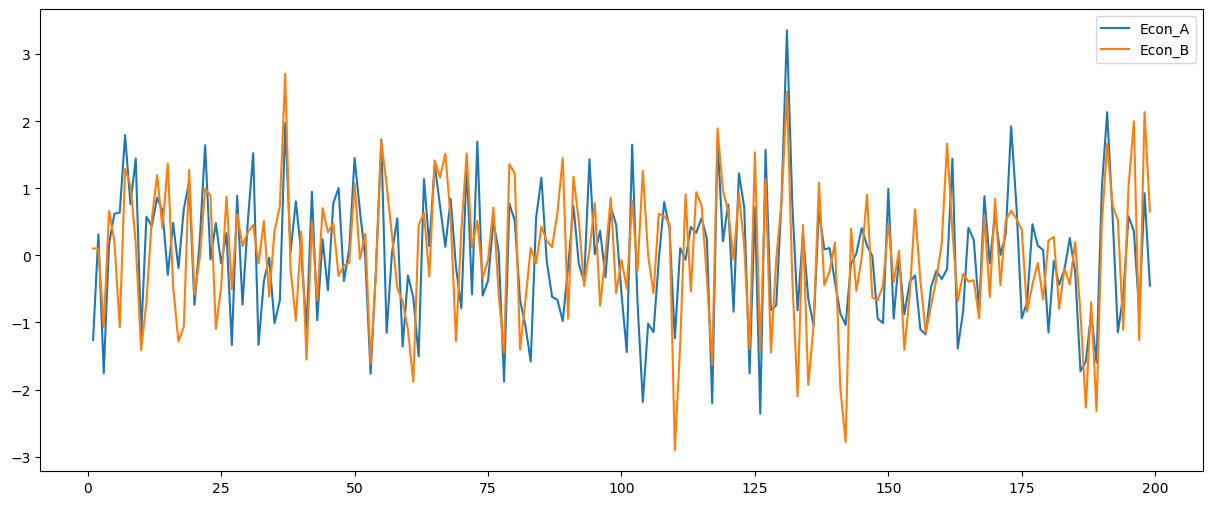

In [16]:
df_diff.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 4) Train Test Split:

In [17]:
len(df_diff)

199

In [19]:
train_data = df_diff[:-12]
test_data = df_diff[-12:]
print(train_data.shape, test_data.shape)

(187, 2) (12, 2)


#### 5) VARMA Model:

In [22]:
model = VARMAX(endog= train_data,
              order= (1, 1),
              trend= 'c',
              enforce_stationarity= False) # enforce_stationarity=False allows fitting even if slightly unstable

result = model.fit(disp= False,
                  maxiter= 1000)

In [23]:
result.summary()

Dep. Variable:,"['Econ_A', 'Econ_B']",No. Observations:,187
Model:,"VARMA(1,1)",Log Likelihood,-458.573
,+ intercept,AIC,943.147
Date:,"Sat, 20 Dec 2025",BIC,985.151
Time:,18:42:50,HQIC,960.167
Sample:,0,,
,- 187,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"0.24, 0.23",Jarque-Bera (JB):,"2.21, 0.82"
Prob(Q):,"0.62, 0.63",Prob(JB):,"0.33, 0.66"
Heteroskedasticity (H):,"1.02, 0.80",Skew:,"0.19, 0.04"


#### 6) Forecast and Invert Transformations:

In [24]:
forecast = result.get_forecast(steps= 12)

In [27]:
df_forecast_diff = forecast.predicted_mean

In [28]:
df_forecast_diff

,Econ_A,Econ_B
187,-0.013993,-0.631986
188,-0.203965,0.432913
189,0.202763,0.006819
190,-0.131323,-0.415287
191,-0.080439,0.487174
192,0.154474,-0.253579
193,-0.181693,-0.141329
194,0.024973,0.380241
195,0.068902,-0.365494
196,-0.169759,0.092559


In [29]:
df_forecast_diff.columns = ['Econ_A_forecast_diff', 'Econ_B_forecast_diff']
df_forecast_diff.head()

,Econ_A_forecast_diff,Econ_B_forecast_diff
187,-0.013993,-0.631986
188,-0.203965,0.432913
189,0.202763,0.006819
190,-0.131323,-0.415287
191,-0.080439,0.487174


##### Invert Transformations:

In [31]:
# Forecast Level = Last_Known_Train_Level + Cumulative_Sum_of_Predicted_Changes

df_forecast = df_forecast_diff.copy()
original_cols = ['Econ_A', 'Econ_B']

for col in original_cols:
    # 1. Get the last actual value from the training set (NOT differenced)
    last_train_value = df[col].iloc[-12-1]
    
    # 2. Cumulatively sum the forecasted differences
    # 3. Add the base value
    df_forecast[f'{col}_forecast'] = last_train_value + df_forecast_diff[f'{col}_forecast_diff'].cumsum()

In [32]:
df_forecast.head()

,Econ_A_forecast_diff,Econ_B_forecast_diff,Econ_A_forecast,Econ_B_forecast
187,-0.013993,-0.631986,95.239683,97.846592
188,-0.203965,0.432913,95.035719,98.279505
189,0.202763,0.006819,95.238482,98.286324
190,-0.131323,-0.415287,95.107159,97.871037
191,-0.080439,0.487174,95.026720,98.358211


##### Model Evaluation:

In [34]:
test_original = df[-12:]

In [35]:
for col in original_cols:
    rmse = np.sqrt(mean_squared_error(test_original[col], df_forecast[f'{col}_forecast']))
    print(f"RMSE for {col}: {rmse:.4f}")

RMSE for Econ_A: 1.0162
RMSE for Econ_B: 2.1527


##### Visualizing Test Data vs Forecast:

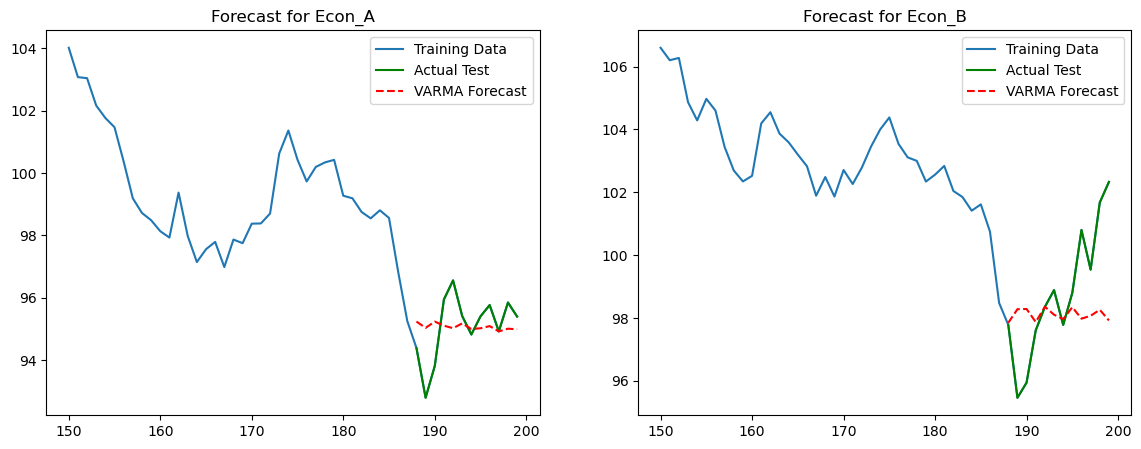

In [36]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

for i, col in enumerate(original_cols):
    # Plot Training Data (Tail)
    axes[i].plot(df[col].iloc[-50:], label='Training Data')
    
    # Plot Actual Test Data
    axes[i].plot(test_original.index, test_original[col], label='Actual Test', color='green')
    
    # Plot Forecast
    axes[i].plot(test_original.index, df_forecast[f'{col}_forecast'], label='VARMA Forecast', color='red', linestyle='--')
    
    axes[i].set_title(f'Forecast for {col}')
    axes[i].legend()

plt.show()